# ***Классификация тональности отзывов Amazon***

## Описание проекта 

Построение модели для автоматического определения тональности отзывов (позитивный/негативный) на основе текста

## Бизнес задача

Автоматизация обработки отзывов для быстрого выявления негативных отзывов и реагирования на проблемы клиентов

## Ключевые результаты 
- **Лучшая модель:** LogisticRegression(class_weight='balanced')
- **Accuracy: 88%**
- **F1-score (positive): 0.92** - отличное качество для позитивных отзывов
- **F1-score (negative): 0.75** - хорошее качество для негативных отзывов (с учетом дисбаланса)
- **Recall (negative): 83%** - находим 83% негативных отзывов
- **Recall (positive): 89%** - находим 89% позитивных отзывов

## Ключевые выводы 
- Текст - основной источник информации
- Признаки полезности, времени и длины текста не показали значимой корреляции с целевой переменной
- Базовая логистическая регрессия оптимальна
- Данные сильно разреженные: 69% продуктов имеют всего 1 отзыв

## Структура проекта
- `notebooks/amazon_sentiment_analysis.ipynb` - полный анализ
- `models/amazon_pipeline.pkl` - пайплайн (препроцессор + модель)
- `results/predictions.csv` - предсказания на тестовой выборке

# 1. Импорт данных и предобработка

In [112]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

import warnings
warnings.filterwarnings('ignore')

In [113]:
reviews = pd.read_csv('../data/Reviews.csv')

**Характеристики датасета:** 

Размер: 568,454 отзыва, 10 признаков 

**Описание признаков датасета:**

- Id - Номер строки в таблице 
- ProductId - Уникальный идентификатор продукта (товара). Всего 74,258 уникальных продуктов
- UserId - Уникальный идентификатор пользователя (кто оставил отзыв). Всего 256,059 уникальных пользователей
- ProfileName - Имя пользователя. Может повторяться у разных UserId
- HelpfulnessNumerator - Число пользователей, которые нашли отзыв ПОЛЕЗНЫМ (Из них сколько нажали "этот отзыв ПОЛЕЗЕН")
- HelpfulnessDenominator - Количество пользователей, указавших, нашли ли они отзыв полезным или нет (Сколько всего человек нажали кнопку "этот отзыв полезен/бесполезен") 
- Score - Оценка. Диапазон: 1-5 звёзд
- Time - Время создания отзыва 
- Summary - Краткое описание отзыва (заголовок)
- Text - Полный текст отзыва

**Предобработка датасета:**

Исходный размер: 568,454 отзыва. Для ускорения взята случайная выборка 30,000 строк (random_state=42 для воспроизводимости)

In [114]:
reviews_sample = reviews.sample(n=30000, random_state=42)

# 2. Разведочный анализ данных (EDA)

In [115]:
reviews_sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30000 entries, 165256 to 282784
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Id                      30000 non-null  int64 
 1   ProductId               30000 non-null  object
 2   UserId                  30000 non-null  object
 3   ProfileName             30000 non-null  object
 4   HelpfulnessNumerator    30000 non-null  int64 
 5   HelpfulnessDenominator  30000 non-null  int64 
 6   Score                   30000 non-null  int64 
 7   Time                    30000 non-null  int64 
 8   Summary                 29999 non-null  object
 9   Text                    30000 non-null  object
dtypes: int64(5), object(5)
memory usage: 2.5+ MB


## 2.1. Распределение оценок 

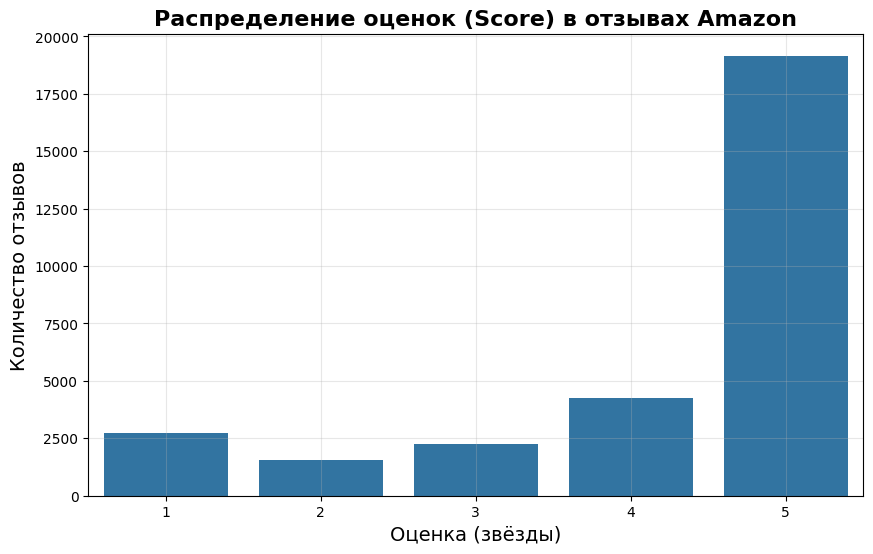

In [116]:
plt.figure(figsize=(10, 6))
sns.countplot(data=reviews_sample, x='Score')
plt.title('Распределение оценок (Score) в отзывах Amazon', fontsize=16, fontweight='bold')
plt.xlabel('Оценка (звёзды)', fontsize=14)
plt.ylabel('Количество отзывов', fontsize=14)
plt.grid(alpha=0.3)

In [117]:
reviews_sample['Score'].value_counts()

Score
5    19160
4     4263
1     2734
3     2271
2     1572
Name: count, dtype: int64

---
**Выводы:**

Сильный дисбаланс классов - 78% отзывов положительные (4-5)

---

## 2.2. Анализ продуктов и пользователей 

In [118]:
top_products = reviews_sample.value_counts('ProductId')
top_10_products = reviews_sample.value_counts('ProductId').head(10)

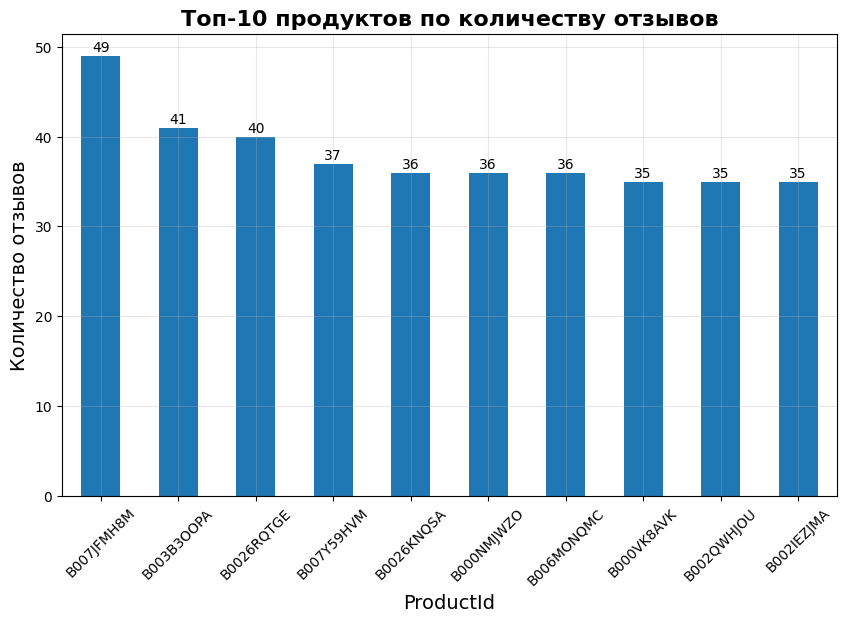

In [119]:
plt.figure(figsize=(10, 6))
top_10_products.plot(kind='bar')
plt.title('Топ-10 продуктов по количеству отзывов', fontsize=16, fontweight='bold')
plt.xlabel('ProductId', fontsize=14)
plt.ylabel('Количество отзывов', fontsize=14)
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

for i, v in enumerate(top_10_products):
    plt.text(i, v + 0.5, str(v), ha='center')

In [120]:
top_users = reviews_sample.value_counts('UserId')
top_10_users = reviews_sample.value_counts('UserId').head(10)

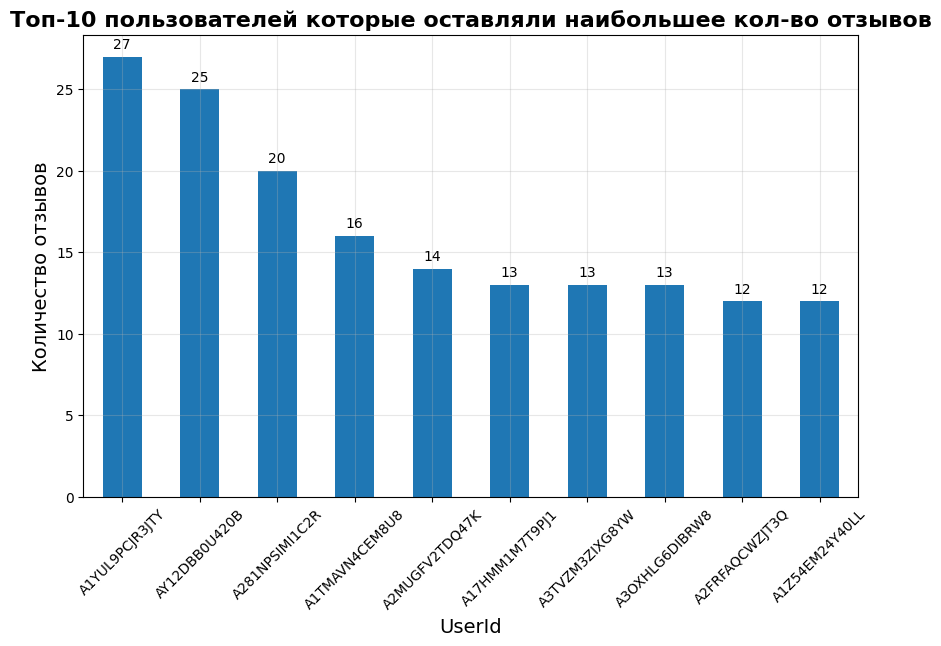

In [121]:
plt.figure(figsize=(10, 6))
top_10_users.plot(kind='bar')
plt.title('Топ-10 пользователей которые оставляли наибольшее кол-во отзывов', fontsize=16, fontweight='bold')
plt.xlabel('UserId', fontsize=14)
plt.ylabel('Количество отзывов', fontsize=14)
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

for i, v in enumerate(top_10_users):
    plt.text(i, v + 0.5, str(v), ha='center')

In [122]:
print('ВЫВОДЫ ИЗ АНАЛИЗА ПРОДУКТОВ И ПОЛЬЗОВАТЕЛЕЙ')

total_reviews = len(reviews_sample)
total_products = reviews_sample['ProductId'].nunique()
total_users = reviews_sample['UserId'].nunique()

products_one_review = sum(top_products[top_products == 1])
products_gt_10_reviews = (top_products >= 10).sum()

print(f'\nКлючевые метрики:')
print(f'Всего отзывов: {total_reviews}')
print(f'Уникальных продуктов: {total_products}')
print(f'Уникальных пользователей: {total_users}')
print(f'Среднее отзывов на продукт: {total_reviews/total_products:.2f}')
print(f'Среднее отзывов на пользователя: {total_reviews/total_users:.2f}')

print(f'\nАнализ продуктов')
print(f'Продуктов с 1 отзывом: {products_one_review} ({(products_one_review / total_products) * 100:.1f} %)')
print(f'Самый популярный продукт: {top_10_products.index[0]} ({top_10_products.iloc[0]} отзывов)')

print(f'\nАнализ пользователей:')
print(f'Самый активный пользователь: {top_users.index[0]} ({top_users.iloc[0]} отзывов)')
print(f'Топ-10 пользователей дали {top_10_users.sum()} отзывов ({top_10_users.sum()/total_reviews * 100:.1f}% от всех)')

ВЫВОДЫ ИЗ АНАЛИЗА ПРОДУКТОВ И ПОЛЬЗОВАТЕЛЕЙ

Ключевые метрики:
Всего отзывов: 30000
Уникальных продуктов: 14740
Уникальных пользователей: 25792
Среднее отзывов на продукт: 2.04
Среднее отзывов на пользователя: 1.16

Анализ продуктов
Продуктов с 1 отзывом: 10176 (69.0 %)
Самый популярный продукт: B007JFMH8M (49 отзывов)

Анализ пользователей:
Самый активный пользователь: A1YUL9PCJR3JTY (27 отзывов)
Топ-10 пользователей дали 165 отзывов (0.5% от всех)


---

**Вывод:**

Данные Amazon сильно разреженные:

- 69% продуктов имеют всего 1 отзыв
- В среднем продукт получает 2 отзыва
- Даже самый популярный продукт имеет только 49 отзывов

---

## 2.3. Анализ полезности отзывов 

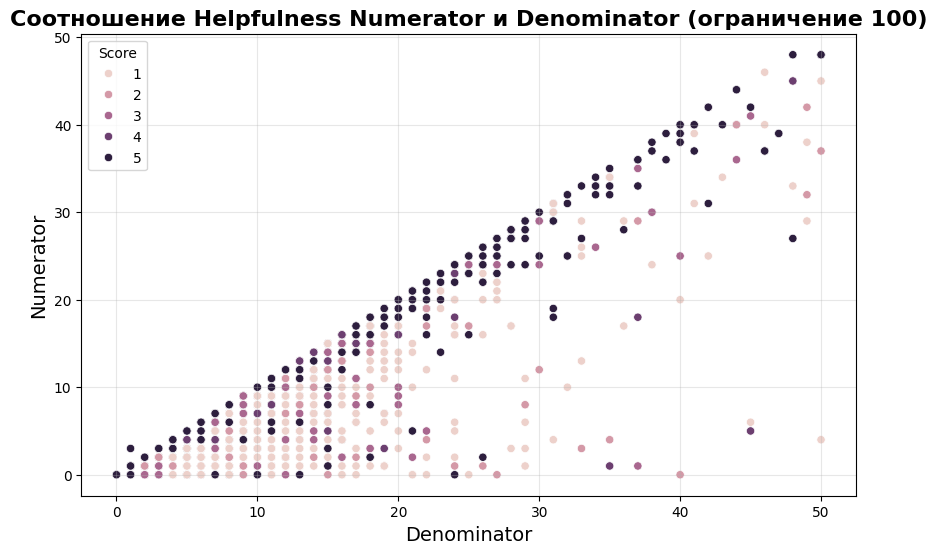

In [123]:
plt.figure(figsize=(10, 6))
filtered = reviews_sample[(reviews_sample['HelpfulnessDenominator'] <= 50)]
sns.scatterplot(data=filtered, x='HelpfulnessDenominator', y='HelpfulnessNumerator',  hue='Score')
plt.title('Соотношение Helpfulness Numerator и Denominator (ограничение 100)', fontsize=16, fontweight='bold')
plt.xlabel('Denominator', fontsize=14)
plt.ylabel('Numerator', fontsize=14)
plt.grid(alpha=0.3)

---
Гипотеза: 

Отзывы с высокими оценками (4-5 звёзд) чаще получают единогласное одобрение полезности (Numerator = Denominator)

---

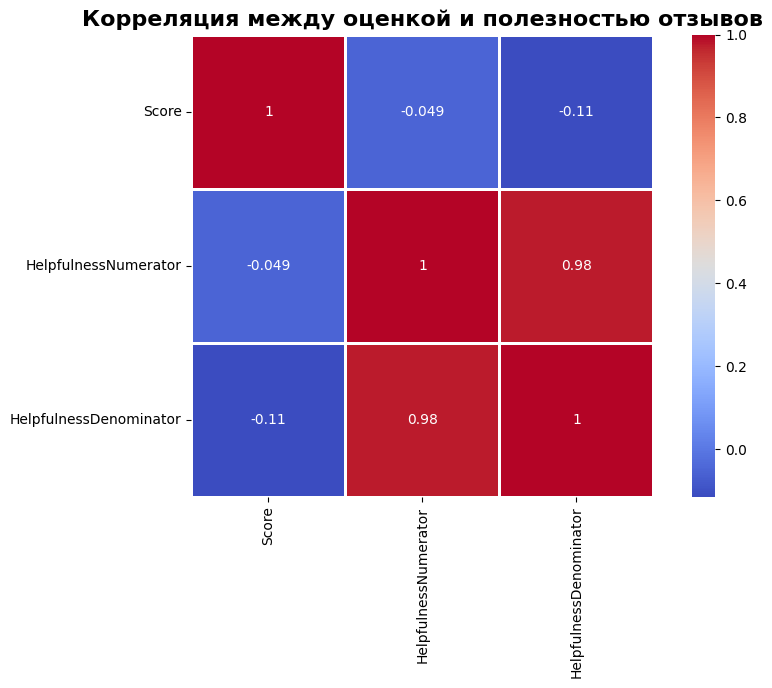

In [124]:
temp_df = reviews_sample[['Score', 'HelpfulnessNumerator', 'HelpfulnessDenominator']].copy()

plt.figure(figsize=(10, 6))
sns.heatmap(temp_df.corr(), annot=True, cmap='coolwarm', linewidths=1, square=True)
plt.title('Корреляция между оценкой и полезностью отзывов', fontsize=16, fontweight='bold');

In [125]:
# Проверка гипотезы
# Создание признака "все нашли отзыв полезным"
reviews_sample['All_Found_Helpful'] = ((reviews_sample['HelpfulnessDenominator'] > 0) & (reviews_sample['HelpfulnessNumerator'] == reviews_sample['HelpfulnessDenominator'])).astype(int)

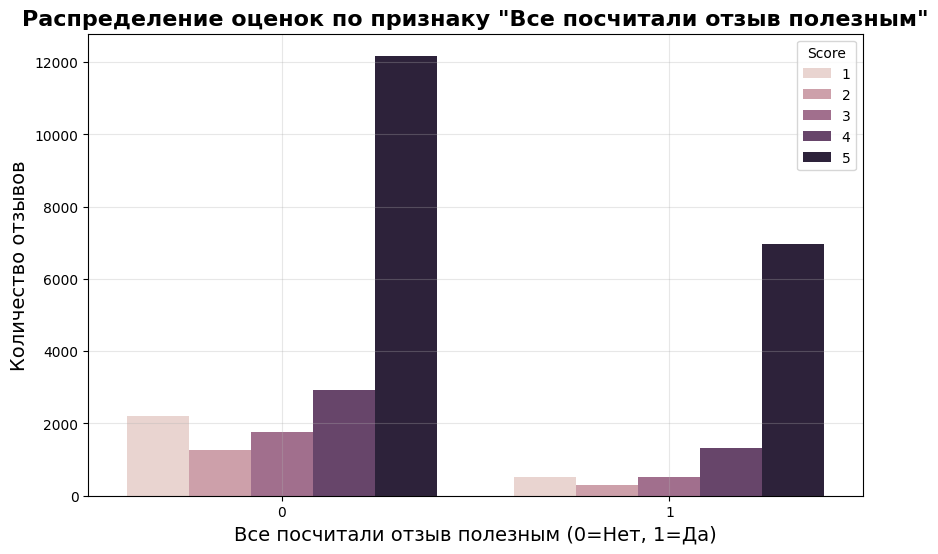

In [126]:
plt.figure(figsize=(10, 6))
sns.countplot(data=reviews_sample, x='All_Found_Helpful', hue='Score')
plt.title('Распределение оценок по признаку "Все посчитали отзыв полезным"', fontsize=16, fontweight='bold') 
plt.xlabel('Все посчитали отзыв полезным (0=Нет, 1=Да)', fontsize=14)
plt.ylabel('Количество отзывов', fontsize=14)
plt.grid(alpha=0.3)

In [127]:
reviews_sample['Score'].corr(reviews_sample[ 'All_Found_Helpful'])

0.13593294844318587

---
Гипотеза: Отзывы с высокими оценками чаще получают 100% полезность

Результат: Гипотеза не подтверждается

Доказательства: 
- Корреляция Score и All_Found_Helpful: 0.136 (слабая)
- График наглядно демонстрирует: столбец оценки "5" высокий в обеих группах. Даже когда отзыв не получил 100% полезности, большинство всё равно имеют высший балл

Вывод: Полезность отзыва слабо связана с оценкой товара

---

## 2.4. Временной анализ 

In [128]:
reviews_sample['Time'] = pd.to_datetime(reviews_sample['Time'], unit='s')
reviews_sample['Time']

165256   2010-03-10
231465   2011-03-01
427827   2008-10-15
433954   2012-04-25
70260    2012-04-18
            ...    
300103   2012-09-29
124651   2010-07-22
214557   2012-01-26
213587   2009-03-30
282784   2010-09-18
Name: Time, Length: 30000, dtype: datetime64[ns]

In [129]:
reviews_sample['Year'] = reviews_sample['Time'].dt.year

In [130]:
year_counts = reviews_sample['Year'].value_counts().sort_index()

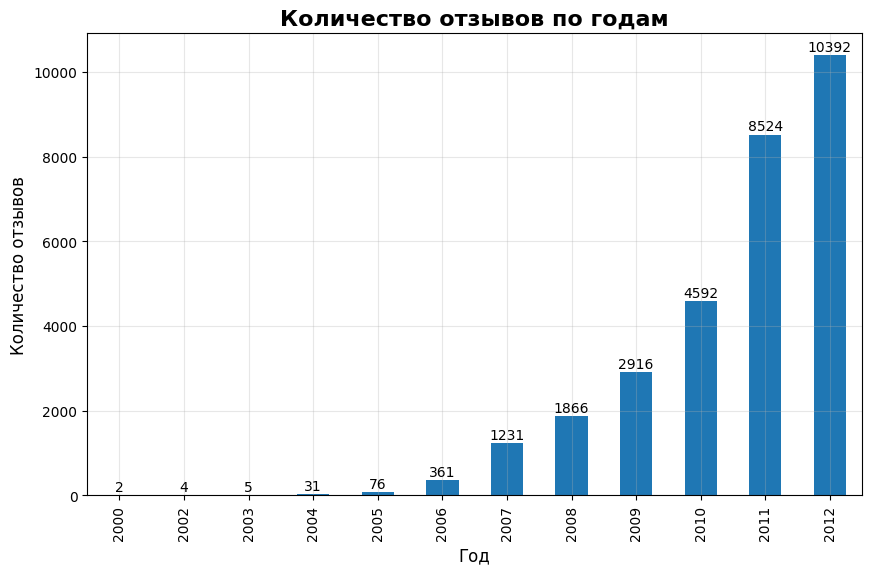

In [131]:
plt.figure(figsize=(10, 6))
year_counts.plot(kind='bar')
plt.title('Количество отзывов по годам', fontsize=16, fontweight='bold')
plt.xlabel('Год', fontsize=12)
plt.ylabel('Количество отзывов', fontsize=12)
plt.grid(alpha=0.3)

for i, v in enumerate(year_counts):
    plt.text(i, v + 100, str(v), ha='center')

In [132]:
avg_score_by_year = reviews_sample.groupby('Year')['Score'].mean()

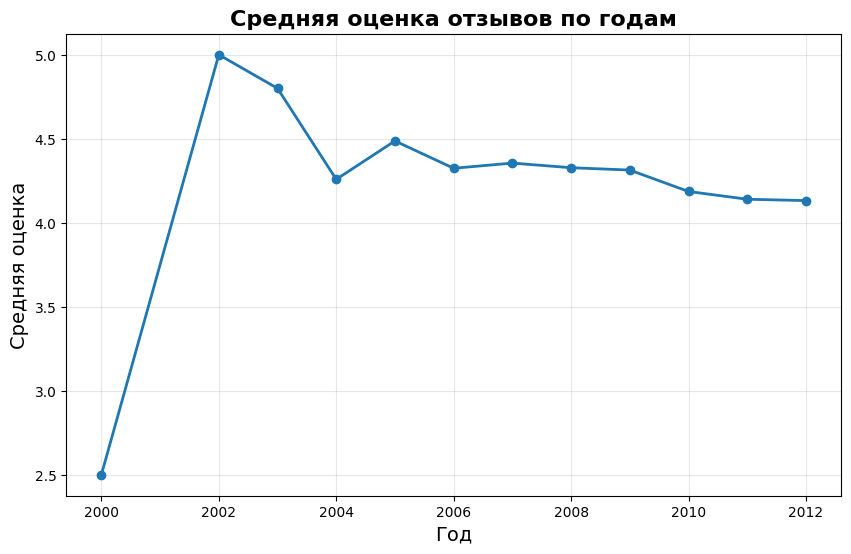

In [133]:
plt.figure(figsize=(10, 6))
avg_score_by_year.plot(marker='o', linewidth=2)
plt.title('Средняя оценка отзывов по годам', fontsize=16, fontweight='bold')
plt.xlabel('Год', fontsize=14)
plt.ylabel('Средняя оценка', fontsize=14)
plt.grid(alpha=0.3)

---
**Вывод:**

Период данных: 2000-2012 годы

Рост активности: от 2 отзывов в 2000 до 10,392 в 2012

Средняя оценка снижается с 4.5 (2005) до 4.13 (2012)

Увеличение количества отзывов сопровождается небольшим снижением средних оценок

---

## 2.5. Анализ длины текста

In [134]:
reviews_sample['Text_Length'] = reviews_sample['Text'].str.len()

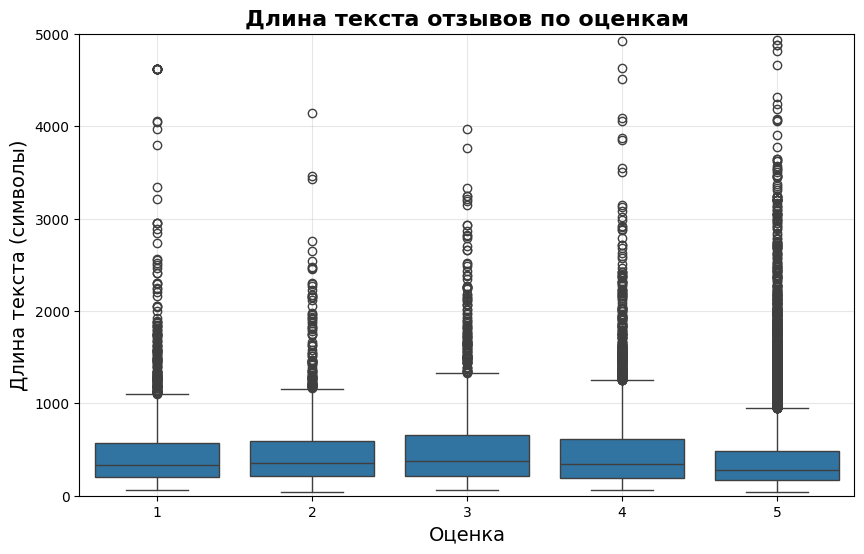

In [135]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=reviews_sample, x='Score', y='Text_Length')
plt.title('Длина текста отзывов по оценкам', fontsize=16, fontweight='bold')
plt.xlabel('Оценка', fontsize=14)
plt.ylabel('Длина текста (символы)', fontsize=14)
plt.ylim(0, 5000) 
plt.grid(alpha=0.3)

In [136]:
reviews_sample.groupby('Score')['Text_Length'].median()

Score
1    335.0
2    355.5
3    380.0
4    348.0
5    276.5
Name: Text_Length, dtype: float64

In [137]:
reviews_sample['Score'].corr(reviews_sample['Text_Length'])

-0.07211286630200475

---
**Вывод:**

Медианная длина по оценкам:
- Оценка 1: 335 символов
- Оценка 2: 356 символов  
- Оценка 3: 380 символов
- Оценка 4: 348 символов
- Оценка 5: 277 символов

Корреляция оценки и длины отзыва: -0.072

Вывод: Практически нет зависимости - разница медиан незначительна, корреляция близка к нулю (-0.072)

---

## 2.6. Итоговые выводы из EDA

1. Ключевые проблемы данных
   - Наблюдается выраженный дисбаланс классов: 78% отзывов имеют положительную оценку (4-5 звёзд)
   - Данные разреженные: 69% товаров имеют всего 1 отзыв, среднее - 2 отзыва на товар
   - Метаданные бесполезны: время, полезность отзыва, длина текста практически не коррелируют с оценкой
2. Стратегия классификации:

   На основе анализа выбрана бинарная классификация:
   
   - negative: оценки 1-3 (негативные и нейтральные отзывы)
   - positive: оценки 4-5 (положительные отзывы)
   - Нейтральный класс (оценка 3) исключён из-за размытых лексических маркеров и отсутствия чётких границ в данных
4. Главный вывод: Только текст отзыва имеет предсказательную силу. Признаки полезности, времени и длины текста не показали значимой корреляции с целевой переменной

---

# 3. Подготовка данных к моделированию

## 3.1. Обработка пропущенных значений 

In [138]:
reviews_sample.isna().sum()

Id                        0
ProductId                 0
UserId                    0
ProfileName               0
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Time                      0
Summary                   1
Text                      0
All_Found_Helpful         0
Year                      0
Text_Length               0
dtype: int64

In [139]:
reviews_sample[reviews_sample['Summary'].isna()]

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,All_Found_Helpful,Year,Text_Length
178290,178291,B00073IVAQ,A3TJPSWY2HE4BS,"S. Layton ""homeschool blogger""",1,24,2,2007-03-08,NaN,I only used two maybe three tea bags and got p...,0,2007,139


In [140]:
reviews_sample = reviews_sample.dropna()

## 3.2. Формирование целевой переменной

Исходная оценка Score имеет 5 градаций (1-5 звёзд), но для задачи классификации тональности достаточно бинарного разделения на положительные и отрицательные отзывы

Граница разделения:

- Оценки 1-3 - negative (негативные/нейтральные отзывы)
- Оценки 4-5 - positive (положительные отзывы)

Такой подход соответствует бизнес-логике Amazon, где отзывы с 4-5 звёздами считаются положительными, а с 1-3 звёздами - отрицательными

Альтернативный вариант с 3 классами (negative/neutral/positive) был рассмотрен в EDA, но нейтральный класс (оценка 3) плохо отделяется и ухудшает качество модели. Бинарная классификация даёт более устойчивые и интерпретируемые результаты

In [141]:
# Группировка Score на два класса
reviews_sample['Score_Cat'] = pd.cut(reviews_sample['Score'], bins=[0, 3, 5], labels=['negative', 'positive'])

## 3.3. Удаление бесполезных признаков 

In [142]:
to_drop = ['Id', 'ProductId', 'UserId', 'ProfileName', 'Score', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Time', 'All_Found_Helpful', 'Year','Text_Length']

reviews_sample = reviews_sample.drop(to_drop, axis=1)

In [143]:
reviews_sample.head()

,Summary,Text,Score_Cat
165256,Crunchy & Good Gluten-Free Sandwich Cookies!,Having tried a couple of other brands of glute...,positive
231465,great kitty treats,My cat loves these treats. If ever I can't fin...,positive
427827,COFFEE TASTE,A little less than I expected. It tends to ha...,negative
433954,So the Mini-Wheats were too big?,"First there was Frosted Mini-Wheats, in origin...",negative
70260,Great Taste . . .,and I want to congratulate the graphic artist ...,positive


---
На основе выводов EDA было установлено, что все не текстовые признаки (полезность отзыва, год, длина текста и др.) имеют крайне слабую корреляцию с целевой переменной (Score_Cat) и не несут полезной информации для предсказания тональности

Корреляции с оценкой:
- HelpfulnessNumerator: -0.05
- HelpfulnessDenominator: -0.11  
- All_Found_Helpful: 0.14
- Year: незначительные колебания
- Text_Length: -0.07

В связи с этим данные признаки были удалены. Финальный набор признаков состоит только из текстовых полей Summary и Text

---

## 3.4. Анализ текста (частотный анализ слов) 

In [144]:
from sklearn.feature_extraction.text import CountVectorizer

In [145]:
for sentiment in ['positive', 'negative']:
    cv = CountVectorizer(stop_words='english')
    matrix = cv.fit_transform(reviews_sample[reviews_sample['Score_Cat'] == sentiment]['Summary'])
    freqs = zip(cv.get_feature_names_out(), matrix.sum(axis=0).tolist()[0])
    top_words = [word for word, count in sorted(freqs, key=lambda x: -x[1])[:10]]
    print(f'{sentiment}: {top_words}')

positive: ['great', 'good', 'best', 'love', 'coffee', 'tea', 'delicious', 'product', 'excellent', 'taste']
negative: ['good', 'taste', 'like', 'great', 'product', 'flavor', 'coffee', 'bad', 'tea', 'ok']


---
**Вывод:**

Положительные отзывы: great, good, best, love, coffee, tea, delicious, product, excellent, taste

Отрицательные отзывы: good, taste, like, great, product, flavor, coffee, bad, tea, ok

1. Уникальные слова-маркеры:
   - Положительные: best, love, delicious, excellent
   - Отрицательные: bad, like, flavor, ok

2. Общие слова (встречаются в обоих классах):
   - good, great, coffee, tea, product, taste
   - TF-IDF автоматически снизит их вес, потому что они часто встречаются 
     и в положительных, и в отрицательных отзывах

3. Вывод для модели:
   - У каждого класса достаточно слов-маркеров для обучения
   - TF-IDF сам разберется с общими словами, снизив их значимость
   - Основной фокус при обучении будет на уникальных словах (best, love, bad и т.д.)

---

## 3.5. Разделение на train и test 

In [146]:
from sklearn.model_selection import train_test_split

In [147]:
X = reviews_sample.drop('Score_Cat', axis=1)
y = reviews_sample['Score_Cat']

In [148]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [149]:
print(f"Train: {X_train.shape[0]} отзывов")
print(f"Test: {X_test.shape[0]} отзывов")

Train: 20999 отзывов
Test: 9000 отзывов


## 3.6. Векторизация текста (TF-IDF)

In [150]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer

In [151]:
preprocessor = ColumnTransformer(
    transformers=[
        ('text_tfidf', TfidfVectorizer(stop_words='english', max_features=5000), 'Text'),
        ('summary_tfidf', TfidfVectorizer(stop_words='english', max_features=5000), 'Summary')
    ]
)

# 4. Построение и оценка моделей 

In [152]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix

## 4.1. Создание pipeline для моделей 

In [153]:
pipeline_nb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', MultinomialNB())
])

In [154]:
pipeline_log_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

In [155]:
pipeline_forest_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(class_weight='balanced'))
])

In [156]:
pipeline_linearSVC_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearSVC(class_weight='balanced'))
])

In [157]:
pipelines = {
    'Naive Bayes': pipeline_nb_model,
    'Logistic Regression': pipeline_log_model,
    'Random Forest': pipeline_forest_model,
    'Linear SVC': pipeline_linearSVC_model
}

### 4.2. Сравнение моделей через кросс-валидацию

Для объективной оценки качества моделей использовалась  кросс-валидация с метрикой F1-macro (усреднённой по двум классам), что позволяет учесть дисбаланс классов

In [158]:
for name, pipeline in pipelines.items():
    scores = cross_val_score(estimator=pipeline, X=X_train, y=y_train, cv=5, scoring='f1_macro')
    print(f'{name}: F1-macro = {scores.mean():.2f}')

Naive Bayes: F1-macro = 0.76
Logistic Regression: F1-macro = 0.83
Random Forest: F1-macro = 0.77
Linear SVC: F1-macro = 0.82


---
**Вывод:**

Logistic Regression и LinearSVC показали наилучшие результаты на кросс-валидации. Обе модели будут протестированы на отложенной тестовой выборке для финального сравнения
 
---

## 4.3. Финальное тестирование лучших моделей 
### 4.3.1. Logistic Regression

              precision    recall  f1-score   support

    negative       0.68      0.83      0.75      1980
    positive       0.95      0.89      0.92      7020

    accuracy                           0.88      9000
   macro avg       0.81      0.86      0.83      9000
weighted avg       0.89      0.88      0.88      9000



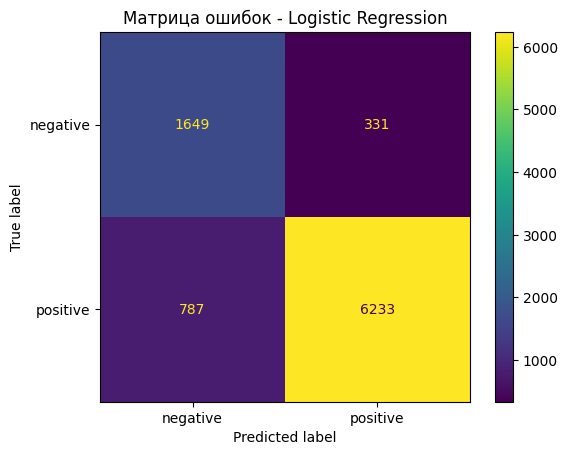

In [49]:
pipeline_log_model.fit(X_train, y_train)
pred_log_model = pipeline_log_model.predict(X_test)
print(classification_report(y_test, pred_log_model))
ConfusionMatrixDisplay.from_predictions(y_test, pred_log_model)
plt.title('Матрица ошибок - Logistic Regression');

---
Результаты: 

- Accuracy: 88%
- Класс positive: F1=0.75 (recall 83%)
- Класс negative: F1=0.92 (recall 89%)
Матрица ошибок показывает что ошибки распределены равномернее 

Вывод: Лучший баланс между классами. class_weight='balanced' работает эффективно

---

              precision    recall  f1-score   support

    negative       0.68      0.77      0.72      1980
    positive       0.93      0.90      0.92      7020

    accuracy                           0.87      9000
   macro avg       0.81      0.83      0.82      9000
weighted avg       0.88      0.87      0.87      9000



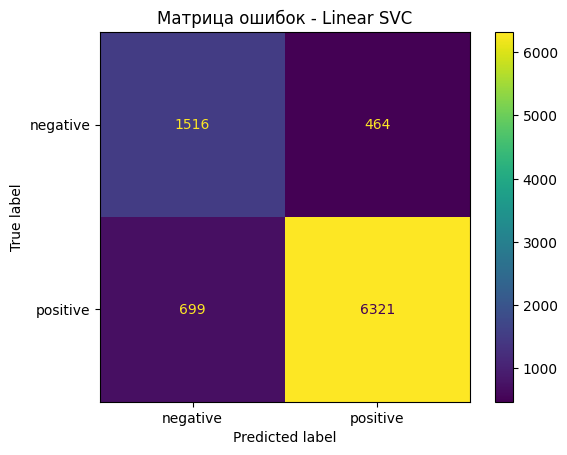

In [50]:
pipeline_linearSVC_model.fit(X_train, y_train)
pred_linearSVC_model = pipeline_linearSVC_model.predict(X_test)
print(classification_report(y_test, pred_linearSVC_model))
ConfusionMatrixDisplay.from_predictions(y_test, pred_linearSVC_model)
plt.title('Матрица ошибок - Linear SVC');

---
Результаты: 

- Accuracy: 87%
- Negative: F1=0.72 (recall 77%)
- Positive: F1=0.92 (recall 90%)

Чуть хуже LogReg по негативному классу

Вывод: LinearSVC дает результат, близкий к LogReg, но немного уступает.

---

## 4.4. Подбор гиперпараметров для логистической регрессии (GridSearchCV)

Хотя базовая модель показала отличные результаты, была проведена проверка возможности улучшения через подбор гиперпараметров

In [51]:
from sklearn.model_selection import GridSearchCV

In [52]:
param_grid = {
    'model__penalty':['l1', 'l2'],
    'model__C': [0.1, 1, 10, 100]
}

In [53]:
grid_model = GridSearchCV(
    estimator=pipeline_log_model, 
    param_grid=param_grid,
    cv=5, 
    scoring='f1_macro', 
    n_jobs=-1
)

In [54]:
grid_model.fit(X_train, y_train)

,estimator,Pipeline(step..._iter=1000))])
,param_grid,"{'model__C': [0.1, 1, ...], 'model__penalty': ['l1', 'l2']}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('text_tfidf', ...), ('summary_tfidf', ...)]"


In [55]:
print(f'Лучшие параметры: {grid_model.best_params_}')

Лучшие параметры: {'model__C': 1, 'model__penalty': 'l2'}


              precision    recall  f1-score   support

    negative       0.68      0.83      0.75      1980
    positive       0.95      0.89      0.92      7020

    accuracy                           0.88      9000
   macro avg       0.81      0.86      0.83      9000
weighted avg       0.89      0.88      0.88      9000



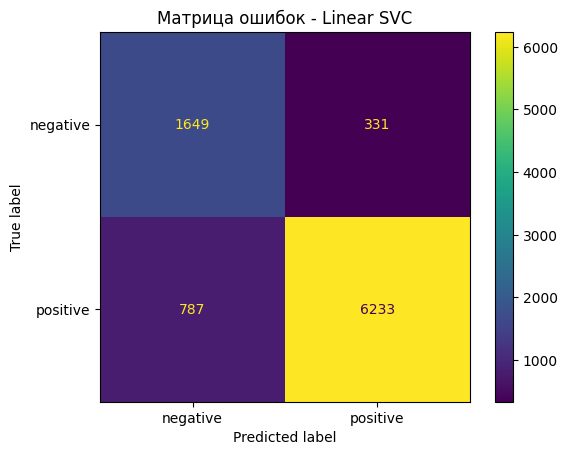

In [56]:
grid_model.fit(X_train, y_train)
pred_grid_model = grid_model.predict(X_test)
print(classification_report(y_test, pred_grid_model))
ConfusionMatrixDisplay.from_predictions(y_test, pred_grid_model)
plt.title('Матрица ошибок - Linear SVC');

---
Результат: 

Проведённый поиск гиперпараметров показал, что оптимальные параметры совпадают с параметрами по умолчанию (C=1, penalty='l2')

Это важный результат, который подтверждает:
- Базовая модель уже оптимальна для данной задачи
- Увеличение параметра C (ослабление регуляризации) не улучшает результат, а при C=10 приводит к лёгкому переобучению

---

# 5. Итоговые результаты 
## 5.1. Сравнение моделей по кросс-валидации

Для объективной оценки качества всех моделей использовалась кросс-валидация с метрикой F1-macro

Naive Bayes и Random Forest отсеяны на этапе кросс-валидации (низкий F1-macro), поэтому не тестировались на отложенной выборке

In [159]:
test_results_df = pd.DataFrame({
    'Модель': ['Naive Bayes', 'Random Forest', 'Logistic Regression', 'Linear SVC'],
    'F1-macro': [0.76, 0.77, 0.83, 0.82],
    'Accuracy': ['-', '-', 0.88, 0.87],
    'F1 (negative)': ['-', '-', 0.75, 0.72],
    'Recall (negative)': ['-', '-', 0.83, 0.77],
    'F1 (positive)': ['-', '-', 0.92, 0.92],
    'Recall (positive)': ['-', '-', 0.89, 0.90]
})

test_results_df

,Модель,F1-macro,Accuracy,F1 (negative),Recall (negative),F1 (positive),Recall (positive)
0,Naive Bayes,0.76,-,-,-,-,-
1,Random Forest,0.77,-,-,-,-,-
2,Logistic Regression,0.83,0.88,0.75,0.83,0.92,0.89
3,Linear SVC,0.82,0.87,0.72,0.77,0.92,0.9


## 5.2. Лучшая модель 

Logistic Regression (C=1, penalty='l2', class_weight='balanced')

Метрики на тесте:

- Accuracy: 88%
- F1-negative: 0.75
- F1-positive: 0.92
- Recall-negative: 83% (находим 83% негативных отзывов)

Почему она лучшая:

- Самый высокий recall на негативном классе
- GridSearch подтвердил оптимальность параметров по умолчанию
- Лучший баланс между классами

## 5.3. Анализ ошибок модели

In [104]:
results = pd.DataFrame({
    'text': X_test['Text'].values,
    'summary': X_test['Summary'].values,
    'true': y_test.values,
    'pred': pipeline_log_model.predict(X_test)
})

errors = results[results['true'] != results['pred']]
print(f"Всего ошибок: {len(errors)}")

Всего ошибок: 1118


### 5.3.1. Ложноположительные результаты (False Positive)

In [109]:
print('Примеры ложноположительных результатов')
false_pos = errors[(errors['pred'] == 'positive') & (errors['true'] == 'negative')]
for i in range(5):
    text = false_pos.iloc[i]['text']
    true_val = false_pos.iloc[i]['true']
    predict = false_pos.iloc[i]['pred']
    print(f'\nТекст: {text[:200]} ... ')
    print(f'\nTrue: {true_val}, Pred: {predict}')
    print('-' * 75) 

Примеры ложноположительных результатов

Текст: It works very well. I wore it all day, then worked out for an hour and I still just smelled like the Degree scent, not BO. However, like most others have said, my armpit has started to itch and burn a ... 

True: negative, Pred: positive
---------------------------------------------------------------------------

Текст: I've bought this candy many times before, although this is my first purchase from this vendor, and might I say the first time I was disapointed. They were edible, but far from fresh. Harder than usual ... 

True: negative, Pred: positive
---------------------------------------------------------------------------

Текст: Muffins with out the mess! Easy portable on the go snack!Kids love them,and adults do too! Quaker is a brand you can trust. ... 

True: negative, Pred: positive
---------------------------------------------------------------------------

Текст: These k cups are great for being green!  I love less plastic and

### 5.3.2. Ложноотрицательные результаты (False Negative)

In [110]:
print('Примеры ложноотрицательных результатов')
false_neg = errors[(errors['pred'] == 'negative') & (errors['true'] == 'positive')]
for i in range(5):
    text = false_neg.iloc[i]['text']
    true_val = false_neg.iloc[i]['true']
    predict = false_neg.iloc[i]['pred']
    print(f'\nТекст: {text[:200]} ... ')
    print(f'\nTrue: {true_val}, Pred: {predict}')
    print('-' * 75) 

Примеры ложноотрицательных результатов

Текст: I've had these before and loved them!  This time I only like them!  Don't know why this is - maybe manufacturer changed recipe.  If so I wish they would go back to the original recipe as I liked them  ... 

True: positive, Pred: negative
---------------------------------------------------------------------------

Текст: I was trying many kinds of espresso. Some were bit too sour, some were too light, and even other kinds of Lavazza didn't work for me. Then, I gave this "Blu" a chance, and since then, I've been sticki ... 

True: positive, Pred: negative
---------------------------------------------------------------------------

Текст: We put this bag to the test on our first use stuffing it full as well as plenty of waste that was full of liquid. The bag was packed so full I had to pull on the bag when taking it out of the kitchen  ... 

True: positive, Pred: negative
-----------------------------------------------------------------------

---
### 5.3.3. Анализ причин ошибок 

Из 9000 отзывов в тестовой выборке модель ошиблась на 1118 (12.4%)

#### Типы ошибок:

- False Positive - Модель посчитала негативный отзыв позитивным 
- False Negative - Модель посчитала позитивный отзыв негативным

#### Примеры ложноположительных ошибок (False Positive)

1. **Отзыв 1 - "It works very well... However, my armpit has started to itch and burn..."**

    Модель увидела "works very well" в начале и проигнорировала проблему в конце
2. **Отзыв 2 - "I've bought this candy many times before... this was the first time I was disapointed"**

    Смешанная тональность: позитивный опыт в прошлом, но текущий негативный

3. **Отзыв 3 - "Muffins with out the mess! Kids love them... Quaker is a brand you can trust"**
   
   Сплошные позитивные фразы, но оценка 1 звезда (возможно сарказм)

4. **Отзыв 4 - "These k cups are great for being green! ... That being said the coffee is pretty good"**

   Отзыв явно позитивный по тексту, возможно в данных имеет Score = 3 (нейтральный), который был перекодирован в negative. Это ошибка разметки, а не модели

5. **Отзыв 5 - "this is probably one of the best sugar free hot chocolate's I've ever tried. That said, it's an adequate replacement..."**

   Начало позитивное, потом "that said" меняет тональность, поэтому модель запуталась

#### Примеры ложноотрицательных ошибок (False Negative)

1. **Отзыв 1 - "I've had these before and loved them! This time I only like them! ... I wish they would go back to the original recipe"**

    Сравнение с прошлым опытом скорее всего запутывает модель

2. **Отзыв 2 - "I was trying many kinds of espresso. Some were bit too sour... Then, I gave this a chance, and since then, I've been sticking with it"**

    Сначала в отзыве сравнение с другими продуктами, поэтому модель засчитала отзыв за негативный

3. **Отзыв 3 - "We put this bag to the test... The bag was packed so full"**

   Описание тестирования без явных маркеров "good/amazing"

4. **Отзыв 4 - "This espresso is much better than I expected... I wasn't expecting much"**

    Конструкция "I wasn't expecting much" может быть неочевидной

6. **Отзыв 5 - "It is the closest thing to a wheat bread taste we could find"**

   Короткий отзыв без явных позитивных слов


#### Основные причины ошибок 

1. Смешанная тональность - отзывы содержат и позитивные, и негативные высказывания
2. Сравнительные конструкции - "better than expected", "not as good as before"
3. Сарказм -  позитивные слова в негативном контексте
4. Короткие тексты - мало контекста для определения тональности

#### Вывод

Модель хорошо работает на явно выраженных отзывах, но ошибается на сложных случаях со смешанной тональностью и сравнительными конструкциями. Это направления для будущего улучшения (например, анализ по частям отзыва или учёт стоп-слов, меняющих тональность)

---

## 5.4. Заключение 

В ходе экспериментов:

- Naive Bayes и Random Forest отсеяны на кросс-валидации (F1-macro 0.76-0.77) из-за сильного смещения в пользу мажорного класса
- LinearSVC показал хороший результат (F1-macro 0.82), но уступил Logistic Regression по recall на негативных отзывах (77% против 83%)
- Logistic Regression — лучшая модель с F1-macro 0.83 на CV и 88% accuracy на тесте
- GridSearchCV подтвердил — параметры по умолчанию (C=1) оптимальны
- Анализ ошибок показал, что модель ошибается в основном на отзывах со смешанной тональностью и сравнительными конструкциями

Финальная модель (LogisticRegression с class_weight='balanced') готова к использованию для автоматической классификации тональности отзывов Amazon.

# 6. Сохранение модели и результатов 

In [58]:
import joblib

In [59]:
joblib.dump(pipeline_log_model, '../models/amazon_pipeline.pkl')

['../models/amazon_pipeline.pkl']

In [60]:
predictions_df = pd.DataFrame({
    'text': X_test['Text'].values,
    'summary': X_test['Summary'].values,
    'actual': y_test.values,
    'predicted': pipeline_log_model.predict(X_test),
})

In [61]:
predictions_df.to_csv('../results/predictions.csv', index=False, encoding='utf-8')